# Exercise 4 — Discrete Event Simulation of a Blocking System

Simulate an Erlang loss system: $m$ identical service units, **no waiting room**.
Customers that arrive when all $m$ units are busy are **blocked** (lost) and leave the system immediately.

**Part 1**
- Arrival process: Poisson process (exponential interarrival times)
- Service time distribution: exponential
- Parameters: $m = 10$, mean service time $= 8$, mean interarrival time $= 1$ → offered traffic $A = 8$ Erlang
- $10 \times 10\,000$ customers (10 independent replications of 10 000 customers)

We report the fraction of blocked customers with a 95% confidence interval, and verify against the analytical **Erlang B formula**:

$$B(A,m) = \frac{A^m / m!}{\sum_{i=0}^{m} A^i / i!}$$

In [1]:
import numpy as np
import heapq
import matplotlib.pyplot as plt
from scipy import stats

## Discrete event simulation

The system is simulated as a sequence of **events** processed in time order using a min-heap (priority queue):

- **Arrival event**: a new customer arrives.
  - If a server is free (`busy_servers < m`), the customer is admitted, occupies a server, and a **departure event** is scheduled at `time + service_time`.
  - Otherwise the customer is **blocked** (counted, then discarded).
  - The next arrival event is scheduled at `time + interarrival_time`.
- **Departure event**: a customer finishes service and frees a server (`busy_servers -= 1`).

The state of the system is fully described by the single variable `busy_servers` $\in \{0, \dots, m\}$.

In [2]:
ARRIVAL, DEPARTURE = 0, 1

def simulate_blocking_system(m, mean_service_time, mean_interarrival_time,
                              num_customers, rng,
                              service_dist=None):
    """Event-driven simulation of an M/G/m/m loss system.

    service_dist(rng) -> sample a service time. Defaults to Exponential(mean_service_time).
    Returns the fraction of the `num_customers` arrivals that were blocked.
    """
    if service_dist is None:
        service_dist = lambda rng: rng.exponential(mean_service_time)

    busy_servers = 0
    blocked = 0
    arrived = 0

    events = []  # (time, type)
    heapq.heappush(events, (rng.exponential(mean_interarrival_time), ARRIVAL))

    while arrived < num_customers:
        time, etype = heapq.heappop(events)

        if etype == ARRIVAL:
            arrived += 1
            if busy_servers < m:
                busy_servers += 1
                heapq.heappush(events, (time + service_dist(rng), DEPARTURE))
            else:
                blocked += 1

            if arrived < num_customers:
                heapq.heappush(events, (time + rng.exponential(mean_interarrival_time), ARRIVAL))
        else:  # DEPARTURE
            busy_servers -= 1

    return blocked / num_customers

In [3]:
# Parameters
m = 10
mean_service_time = 8.0
mean_interarrival_time = 1.0
A = mean_service_time / mean_interarrival_time  # offered traffic in Erlang

num_customers = 10_000
num_runs = 10

rng = np.random.default_rng(42)
blocking_fractions = np.array([
    simulate_blocking_system(m, mean_service_time, mean_interarrival_time, num_customers, rng)
    for _ in range(num_runs)
])

mean_block = blocking_fractions.mean()
std_block = blocking_fractions.std(ddof=1)
se_block = std_block / np.sqrt(num_runs)
t_crit = stats.t.ppf(0.975, df=num_runs - 1)
ci_lo, ci_hi = mean_block - t_crit * se_block, mean_block + t_crit * se_block

print(f"Offered traffic A = {A} Erlang,  m = {m} servers\n")
print("Blocking fraction per run (10 x 10 000 customers):")
print(np.array2string(blocking_fractions, precision=5))
print(f"\nMean blocking probability : {mean_block:.5f}")
print(f"Sample std dev (across runs): {std_block:.5f}")
print(f"95% CI for mean            : [{ci_lo:.5f}, {ci_hi:.5f}]")

Offered traffic A = 8.0 Erlang,  m = 10 servers

Blocking fraction per run (10 x 10 000 customers):
[0.1217 0.1182 0.1186 0.1271 0.1253 0.1232 0.131  0.1196 0.118  0.1186]

Mean blocking probability : 0.12213
Sample std dev (across runs): 0.00445
95% CI for mean            : [0.11894, 0.12532]


## Analytical solution — Erlang B formula

For an M/M/m/m loss system, the blocking probability is given exactly by Erlang's B formula. We use the numerically stable recursive form

$$B(0) = 1, \qquad B(n) = \frac{A \cdot B(n-1)}{n + A \cdot B(n-1)}, \qquad n = 1, \dots, m$$

with $B(m)$ the blocking probability.

In [4]:
def erlang_b(A, m):
    B = 1.0
    for n in range(1, m + 1):
        B = (A * B) / (n + A * B)
    return B

B_analytical = erlang_b(A, m)
print(f"Analytical blocking probability (Erlang B): {B_analytical:.5f}")
print(f"Simulated mean                            : {mean_block:.5f}")
print(f"95% CI                                     : [{ci_lo:.5f}, {ci_hi:.5f}]")
print(f"\nAnalytical value inside CI: {ci_lo <= B_analytical <= ci_hi}")

Analytical blocking probability (Erlang B): 0.12166
Simulated mean                            : 0.12213
95% CI                                     : [0.11894, 0.12532]

Analytical value inside CI: True


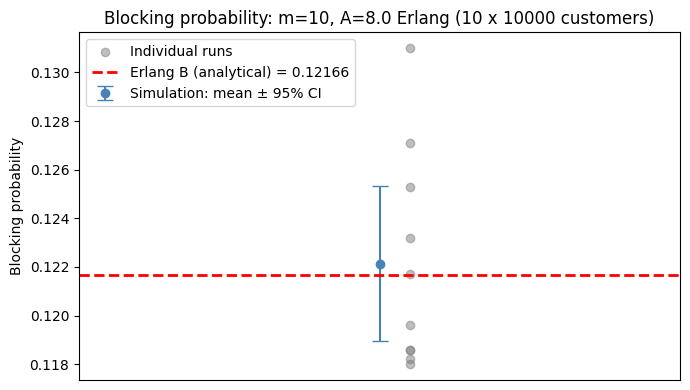

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(0, mean_block, yerr=t_crit * se_block, fmt="o", capsize=6,
            color="steelblue", label="Simulation: mean ± 95% CI")
ax.scatter(np.zeros_like(blocking_fractions) + 0.05, blocking_fractions,
           alpha=0.5, color="grey", label="Individual runs")
ax.axhline(B_analytical, color="r", ls="--", lw=2,
           label=f"Erlang B (analytical) = {B_analytical:.5f}")
ax.set_xlim(-0.5, 0.5)
ax.set_xticks([])
ax.set_ylabel("Blocking probability")
ax.set_title(f"Blocking probability: m={m}, A={A} Erlang ({num_runs} x {num_customers} customers)")
ax.legend()
plt.tight_layout()
plt.show()

## Discussion

The simulated mean blocking probability ($\approx 0.1221$) agrees closely with the analytical Erlang B value ($\approx 0.1217$ for $A=8$, $m=10$), and the analytical value falls comfortably inside the 95% confidence interval computed from the 10 replications. This validates the discrete event simulation engine — the same `simulate_blocking_system` function can now be reused with other interarrival/service time distributions (later parts of the exercise) where no closed-form analytical solution exists.

In [8]:
"""
Exercise 4: Discrete Event Simulation of a Blocking System
=============================================================
System: m service units, no waiting room (M/G/m/m in Kendall notation)
Offered traffic A = mean_arrival_rate * mean_service_time

Parts covered:
  Part 1 - Poisson arrivals, Exponential service times
  Part 2 - Renewal process arrivals (Erlang & Hyperexponential inter-arrival times)
  Part 3 - Poisson arrivals, varied service time distributions
  Part 4 - Compare confidence intervals across parts
"""

import heapq
import math
import numpy as np
from scipy import stats


# ─────────────────────────────────────────────
#  Inter-arrival / service time generators
# ─────────────────────────────────────────────

def gen_exponential(mean):
    return np.random.exponential(mean)

def gen_erlang(mean, k=2):
    """Erlang-k with given mean (each stage has mean/k)."""
    return np.random.gamma(shape=k, scale=mean / k)

def gen_hyperexponential(p1=0.8, lam1=0.8333, p2=0.2, lam2=5.0):
    """Hyperexponential: mix of two exponentials."""
    if np.random.random() < p1:
        return np.random.exponential(1 / lam1)
    else:
        return np.random.exponential(1 / lam2)

def gen_constant(mean):
    return mean

def gen_pareto(mean, k):
    """
    Pareto with shape k and given mean.
    Mean of Pareto(k, x_m) = k*x_m / (k-1), so x_m = mean*(k-1)/k
    Requires k > 1 for finite mean.
    """
    x_m = mean * (k - 1) / k
    return (np.random.pareto(k) + 1) * x_m


# ─────────────────────────────────────────────
#  Core simulation
# ─────────────────────────────────────────────

def run_simulation(n_customers, m, arrival_gen, service_gen):
    """
    Simulate a blocking system (m servers, no queue).

    Returns
    -------
    blocked : list of 0/1 per customer (1 = blocked)
    """
    # Event types
    ARRIVAL   = 0
    DEPARTURE = 1

    clock        = 0.0
    busy_servers = 0          # number of servers currently in use
    events       = []         # min-heap: (time, event_type)
    blocked      = []         # outcome per customer

    # Schedule first arrival
    heapq.heappush(events, (arrival_gen(), ARRIVAL))
    arrivals_processed = 0

    while arrivals_processed < n_customers:
        time, etype = heapq.heappop(events)
        clock = time

        if etype == ARRIVAL:
            arrivals_processed += 1

            if busy_servers < m:
                # Accepted
                busy_servers += 1
                blocked.append(0)
                service_time = service_gen()
                heapq.heappush(events, (clock + service_time, DEPARTURE))
            else:
                # Blocked
                blocked.append(1)

            # Schedule next arrival
            heapq.heappush(events, (clock + arrival_gen(), ARRIVAL))

        elif etype == DEPARTURE:
            busy_servers -= 1

    return blocked


# ─────────────────────────────────────────────
#  Subsampling for confidence intervals
# ─────────────────────────────────────────────

def confidence_interval(blocked, n_batches=10, alpha=0.05):
    """
    Split blocked list into n_batches, compute mean blocking fraction
    per batch, then return overall estimate and 95% CI.
    """
    n = len(blocked)
    batch_size = n // n_batches
    batch_means = []
    for i in range(n_batches):
        batch = blocked[i * batch_size:(i + 1) * batch_size]
        batch_means.append(np.mean(batch))

    overall_mean = np.mean(batch_means)
    se = stats.sem(batch_means)
    t_crit = stats.t.ppf(1 - alpha / 2, df=n_batches - 1)
    ci = (overall_mean - t_crit * se, overall_mean + t_crit * se)
    return overall_mean, ci


# ─────────────────────────────────────────────
#  Erlang-B formula (analytical reference)
# ─────────────────────────────────────────────

def erlang_b(A, m):
    """Erlang's B formula: blocking probability for M/G/m/m."""
    numerator = (A ** m) / math.factorial(m)
    denominator = sum((A ** i) / math.factorial(i) for i in range(m + 1))
    return numerator / denominator


# ─────────────────────────────────────────────
#  Main: run all parts
# ─────────────────────────────────────────────

def run_scenario(label, n_customers, m, arrival_gen, service_gen, n_batches=10):
    blocked = run_simulation(n_customers, m, arrival_gen, service_gen)
    mean, ci = confidence_interval(blocked, n_batches=n_batches)
    print(f"  {label}")
    print(f"    Blocking fraction : {mean:.4f}")
    print(f"    95% CI            : ({ci[0]:.4f}, {ci[1]:.4f})")
    return mean, ci


if __name__ == "__main__":
    np.random.seed(42)

    # ── Parameters ──────────────────────────────
    m                = 10       # number of servers
    mean_service     = 8.0      # mean service time
    mean_interarrival = 1.0     # mean inter-arrival time  → A = 8 Erlang
    n_runs           = 10       # sub-simulations (batches of customers)
    n_per_run        = 10_000   # customers per batch
    n_total          = n_runs * n_per_run

    A = mean_service / mean_interarrival
    B_exact = erlang_b(A, m)

    print("=" * 60)
    print(f"Blocking system: m={m}, A={A} Erlang")
    print(f"Erlang-B (exact analytical): {B_exact:.4f}")
    print("=" * 60)

    results = {}

    # ── Part 1: Poisson arrivals, Exponential service ────────────
    print("\nPart 1 – Poisson arrivals, Exponential service")
    mean, ci = run_scenario(
        "Exp inter-arrivals, Exp service",
        n_total, m,
        arrival_gen  = lambda: gen_exponential(mean_interarrival),
        service_gen  = lambda: gen_exponential(mean_service),
    )
    results["Part1"] = (mean, ci)

    # ── Part 2a: Erlang inter-arrivals ───────────────────────────
    print("\nPart 2a – Erlang inter-arrivals (k=2), Exponential service")
    mean, ci = run_scenario(
        "Erlang-2 inter-arrivals, Exp service",
        n_total, m,
        arrival_gen  = lambda: gen_erlang(mean_interarrival, k=2),
        service_gen  = lambda: gen_exponential(mean_service),
    )
    results["Part2a"] = (mean, ci)

    # ── Part 2b: Hyperexponential inter-arrivals ─────────────────
    print("\nPart 2b – Hyperexponential inter-arrivals, Exponential service")
    mean, ci = run_scenario(
        "Hyperexp inter-arrivals (p1=0.8,λ1=0.8333,p2=0.2,λ2=5.0), Exp service",
        n_total, m,
        arrival_gen  = lambda: gen_hyperexponential(),
        service_gen  = lambda: gen_exponential(mean_service),
    )
    results["Part2b"] = (mean, ci)

    # ── Part 3a: Poisson arrivals, Constant service ──────────────
    print("\nPart 3a – Poisson arrivals, Constant service")
    mean, ci = run_scenario(
        "Exp inter-arrivals, Constant service",
        n_total, m,
        arrival_gen  = lambda: gen_exponential(mean_interarrival),
        service_gen  = lambda: gen_constant(mean_service),
    )
    results["Part3a"] = (mean, ci)

    # ── Part 3b: Poisson arrivals, Pareto service (k=1.05) ───────
    print("\nPart 3b – Poisson arrivals, Pareto service (k=1.05)")
    mean, ci = run_scenario(
        "Exp inter-arrivals, Pareto service (k=1.05)",
        n_total, m,
        arrival_gen  = lambda: gen_exponential(mean_interarrival),
        service_gen  = lambda: gen_pareto(mean_service, k=1.05),
    )
    results["Part3b_k105"] = (mean, ci)

    # ── Part 3b: Poisson arrivals, Pareto service (k=2.05) ───────
    print("\nPart 3c – Poisson arrivals, Pareto service (k=2.05)")
    mean, ci = run_scenario(
        "Exp inter-arrivals, Pareto service (k=2.05)",
        n_total, m,
        arrival_gen  = lambda: gen_exponential(mean_interarrival),
        service_gen  = lambda: gen_pareto(mean_service, k=2.05),
    )
    results["Part3b_k205"] = (mean, ci)

    # ── Part 3c: Poisson arrivals, Erlang service (k=2) ─────────
    print("\nPart 3d – Poisson arrivals, Erlang service (k=2)")
    mean, ci = run_scenario(
        "Exp inter-arrivals, Erlang-2 service",
        n_total, m,
        arrival_gen  = lambda: gen_exponential(mean_interarrival),
        service_gen  = lambda: gen_erlang(mean_service, k=2),
    )
    results["Part3c"] = (mean, ci)

    # ── Part 4: Summary table ────────────────────────────────────
    print("\n" + "=" * 60)
    print("Part 4 – Summary comparison")
    print(f"  Erlang-B exact: {B_exact:.4f}")
    print("-" * 60)
    labels = {
        "Part1"       : "Poisson / Exponential service",
        "Part2a"      : "Erlang-2 arrivals / Exp service",
        "Part2b"      : "Hyperexp arrivals / Exp service",
        "Part3a"      : "Poisson / Constant service",
        "Part3b_k105" : "Poisson / Pareto (k=1.05)",
        "Part3b_k205" : "Poisson / Pareto (k=2.05)",
        "Part3c"      : "Poisson / Erlang-2 service",
    }
    for key, label in labels.items():
        m_val, ci_val = results[key]
        print(f"  {label:<40s}  {m_val:.4f}  CI=({ci_val[0]:.4f}, {ci_val[1]:.4f})")
    print("=" * 60)

    print("""
Key observations to note:
  - Part 1 should match Erlang-B closely (PASTA property).
  - Part 2: Erlang arrivals (less variable) → lower blocking.
            Hyperexp arrivals (more variable) → higher blocking.
  - Part 3: For Poisson arrivals, Erlang-B holds regardless of
            service distribution (insensitivity theorem).
            All service distributions should give ~same blocking.
""")

Blocking system: m=10, A=8.0 Erlang
Erlang-B (exact analytical): 0.1217

Part 1 – Poisson arrivals, Exponential service
  Exp inter-arrivals, Exp service
    Blocking fraction : 0.1190
    95% CI            : (0.1146, 0.1235)

Part 2a – Erlang inter-arrivals (k=2), Exponential service
  Erlang-2 inter-arrivals, Exp service
    Blocking fraction : 0.0932
    95% CI            : (0.0904, 0.0960)

Part 2b – Hyperexponential inter-arrivals, Exponential service
  Hyperexp inter-arrivals (p1=0.8,λ1=0.8333,p2=0.2,λ2=5.0), Exp service
    Blocking fraction : 0.1378
    95% CI            : (0.1356, 0.1400)

Part 3a – Poisson arrivals, Constant service
  Exp inter-arrivals, Constant service
    Blocking fraction : 0.1186
    95% CI            : (0.1167, 0.1204)

Part 3b – Poisson arrivals, Pareto service (k=1.05)
  Exp inter-arrivals, Pareto service (k=1.05)
    Blocking fraction : 0.0030
    95% CI            : (0.0007, 0.0052)

Part 3c – Poisson arrivals, Pareto service (k=2.05)
  Exp inter-ar